## 9ª Tarefa de Oficina de Modelagem e Simulação

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 23 de maio de 2026  

---

### Descrição
Exercícios computacionais

In [10]:
"""
    1. Dada a equação diferencial de 3ª ordem x''' + x'' + 2x' + x = 2f(t), represente-a no espaço de 
    estados e em função de transferência considerando a saída y = x. Dica: utilize o comando ss2tf
"""

"""
    Vamos usar: x1 = x, x2 = x' e x3 = x''. 
    Então:
    x1' = x2
    x2' = x3
    x3' = - x3 - 2*x2 - x1 + 2f(t)
"""

import control
import numpy as np

# Matrizes x' = Ax + Bu
A = np.array([
    [0, 1, 0],
    [0, 0, 1],
    [-1, -2, -1]
])

B = np.array([
    [0],
    [0],
    [2]
])

# Matrizes y = Cx + Du
C = np.array([
    [1, 0, 0]
])

D = np.array([
    [0]
])

# Sistema em state-space
sys_ss = control.ss(A, B, C, D)

print("Sistema em espaço de estados:")
print(sys_ss)


# Conversão para função de transferência
sys_tf = control.ss2tf(sys_ss)

print("\nFunção de transferência:")
print(sys_tf)



Sistema em espaço de estados:
<StateSpace>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[ 0.  1.  0.]
     [ 0.  0.  1.]
     [-1. -2. -1.]]

B = [[0.]
     [0.]
     [2.]]

C = [[1. 0. 0.]]

D = [[0.]]

Função de transferência:
<TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.887e-15 s^2 + 4.885e-15 s + 2
  -------------------------------
        s^3 + s^2 + 2 s + 1


In [3]:
"""
    2. Dado o sistema mecânico rotacional da figura 3, cujo modelo matemático á dado pelo
    sistema de equações diferenciais (sistema no código).
    
    a) a representação no espaço de estados e em função de transferência, sendo T (t) a
    entrada e θ1(t) a saída;
    b) a representação no espaço de estados e matriz de transferência, sendo T (t) a entrada
    e θ1(t) e θ2(t) as saídas
"""
"""
   Equações diferenciais (já isoladas):
   0_1'' = -3*0_1 + 2*0_2 + T
   0_2'' = 0_1 - (5/2)*0_2 

   Variáveis de estado:
   x1 = 0_1
   x2 = 0_2
   x3 = 0_1'
   x4 = 0_2'

   Sistema de equações:
    x1' = x3
    x2' = x4
    x3' = -3*x1 + 2*x2 + T
    x4' = x1 - (5/2)*x2
"""
import control as ctrl
import numpy as np

# Matrizes x' = Ax + Bu
A = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [-3, 2, 0, 0],
    [1, -2.5, 0, 0]
])

B = np.array([
    [0],
    [0],
    [1],
    [0]
])

# Matrizes Y = Cx + Du para a parte a)
C1 = np.array([
    [1, 0, 0, 0]
])

D1 = np.array([
    [0]
])


sys_ss1 = ctrl.ss(A, B, C1, D1)
sys_tf1 = ctrl.ss2tf(sys_ss1)

print("Espaço de estadosA:")
print(sys_ss1)
print("\nFunção de transferênciaA:")
print(sys_tf1)

# Matrizes Y = Cx + Du para a parte b)
C2 = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

D2 = np.array([
    [0],
    [0]
])

sys_ss2 = ctrl.ss(A, B, C2, D2)
sys_tf2 = ctrl.ss2tf(sys_ss2)

print("Espaço de estadosB:")
print(sys_ss2)
print("\nFunção de transferênciaB:")
print(sys_tf2)



Espaço de estadosA:
<StateSpace>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.   0.   1.   0. ]
     [ 0.   0.   0.   1. ]
     [-3.   2.   0.   0. ]
     [ 1.  -2.5  0.   0. ]]

B = [[0.]
     [0.]
     [1.]
     [0.]]

C = [[1. 0. 0. 0.]]

D = [[0.]]

Função de transferênciaA:
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      -6.828e-17 s^3 + s^2 - 1.487e-16 s + 2.5
  -------------------------------------------------
  s^4 + 5.551e-17 s^3 + 5.5 s^2 + 1.277e-16 s + 5.5
Espaço de estadosB:
<StateSpace>: sys[10]
Inputs (1): ['u[0]']
Outputs (2): ['y[0]', 'y[1]']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.   0.   1.   0. ]
     [ 0.   0.   0.   1. ]
     [-3.   2.   0.   0. ]
     [ 1.  -2.5  0.   0. ]]

B = [[0.]
     [0.]
     [1.]
     [0.]]

C = [[1. 0. 0. 0.]
     [0. 1. 0. 0.]]

D = [[0.]
     [0.]]

Função de transferênciaB:
<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (

In [5]:
"""
    3. Linearize a equação não linear z = xy no intervalo 5 ≤ x ≤ 7 e 10 ≤ y ≤ 12. Encontre o
    erro de aproximação quando x = 5 e y = 10
"""

import sympy as sp

# Variáveis simbólicas
x, y = sp.symbols('x y')

# Função não linear
z = x*y

# Ponto de operação
x0 = 6
y0 = 11

# Valor da função no ponto
z0 = z.subs({x: x0, y: y0})

# Derivadas parciais
dz_dx = sp.diff(z, x)
dz_dy = sp.diff(z, y)

# Avaliando no ponto de operação
dz_dx0 = dz_dx.subs({x: x0, y: y0})
dz_dy0 = dz_dy.subs({x: x0, y: y0})

# Avaliando no ponto de operação
dz_dx0 = dz_dx.subs({x: x0, y: y0})
dz_dy0 = dz_dy.subs({x: x0, y: y0})

# Linearização de Taylor de primeira ordem
z_lin = z0 + dz_dx0*(x - x0) + dz_dy0*(y - y0)

# Simplificando
z_lin = sp.expand(z_lin)

print("Função linearizada:")
print(z_lin)

# Valor real em (5,10)
z_real = z.subs({x: 5, y: 10})

# Valor aproximado
z_aprox = z_lin.subs({x: 5, y: 10})

# Erro
erro = abs(z_real - z_aprox)

print("\nValor real:", z_real)
print("Valor aproximado:", z_aprox)
print("Erro:", erro)




Função linearizada:
11*x + 6*y - 66

Valor real: 50
Valor aproximado: 49
Erro: 1


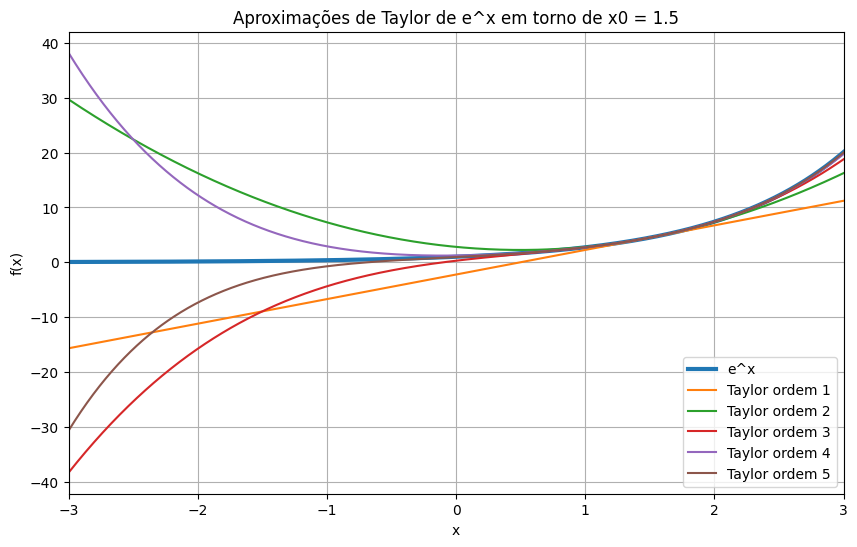

In [6]:
"""
    4. Defina uma variável simbólica x. Encontre a expansão em série de Taylor de f (x) = e^x
    em torno do ponto 1.5. Construa apenas um gráfico contendo seis funções. São elas: a
    função original f (x) e as séries de Taylor truncadas até os termos de 5ª, 4ª, ..., 1ª ordem.
    Comente o ocorrido. PS.: Escolha a escala do eixo das abscissas entre -3 e 3 para uma
    melhor visualização do gráfico
"""

import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.symbols('x') # Variável simbólica
f = sp.exp(x) # Função original
x0 = 1.5 # Ponto de expansão
t = np.linspace(-3, 3, 1000) # Intervalo do gráfico

f_original = sp.lambdify(x, f, 'numpy') # Função numérica da função original


#Figura para o gráfico
plt.figure(figsize=(10, 6))

# Plot da função original
plt.plot(t, f_original(t), label='e^x', linewidth=3)

# Geração das séries de Taylor
for ordem in range(1, 6):

    # Série de Taylor truncada
    taylor = sp.series(f, x, x0, ordem + 1).removeO()

    # Converte para função numérica
    taylor_num = sp.lambdify(x, taylor, 'numpy')

    # Plot
    plt.plot(
        t,
        taylor_num(t),
        label=f'Taylor ordem {ordem}'
    )

# Configurações do gráfico
plt.xlim([-3, 3])
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Aproximações de Taylor de e^x em torno de x0 = 1.5')
plt.grid(True)
plt.legend()
plt.show()


Função original:
sin(5*x) + cos(x)

Aproximação linear:
625*x**5/24 + x**4/24 - 125*x**3/6 - x**2/2 + 5*x + 1


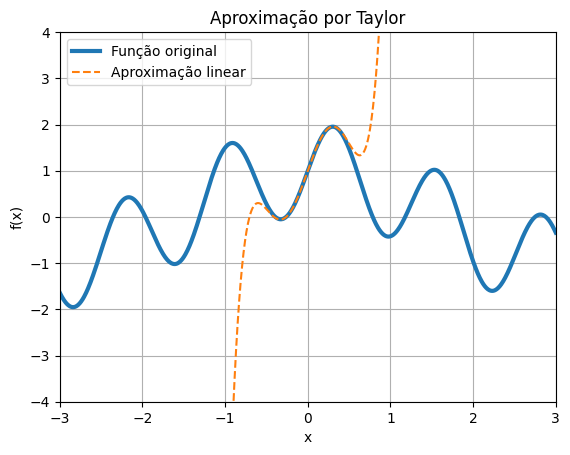

In [ ]:
"""
    5. Escolha uma função senoidal. Obtenha uma aproximação linear em torno de um ponto
    qualquer usando série de Taylor. Faça as suposições necessárias. Mostre as funções
    original e aproximada na janela de comando e em gráfico.

    Vamos aproximar a função f(x) = cos(x) + sin(5x) em torno do ponto x0 = 0.
"""

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Variável simbólica
x = sp.symbols('x')

# Função original
f = sp.cos(x) + sp.sin(5*x)

# Ponto de expansão
x0 = 0

# Série de Taylor de 5ª ordem
f_lin = sp.series(f, x, x0, 6).removeO()

# Mostrar funções na tela
print("Função original:")
print(f)

print("\nAproximação linear:")
print(f_lin)

# Converter para funções numéricas
f_num = sp.lambdify(x, f, 'numpy')
f_lin_num = sp.lambdify(x, f_lin, 'numpy')

# Intervalo do gráfico
t = np.linspace(-3, 3, 1000)

# Plot
plt.plot(t, f_num(t), label='Função original', linewidth=3)

plt.plot(
    t,
    f_lin_num(t),
    label='Aproximação linear',
    linestyle='--'
)

# Configurações
plt.xlim([-3, 3])
plt.ylim([-4, 4])
plt.title('Aproximação por Taylor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

In [15]:
"""
    6. Dado o modelo não linear que descreve o comportamento cinemático de um robô móvel
    diferencial apresentado na Figura 4:

    x' = f(x, u)

    x' = v*cos(theta)
    y' = v*sin(theta)
    theta' = w

    Obtenha o modelo linearizado em torno do ponto de equilíbrio (x0, y0, θ0, v0, ω0).
    Comandos úteis: ss, ss2tf, tf2ss, zp2tf, zp2ss, ss2zp, taylor, eig 
"""

import sympy as sp

# Variáveis simbólicas
x, y, theta = sp.symbols('x y theta')
v, w = sp.symbols('v w')

# Vetor de estados
X = sp.Matrix([
    x,
    y,
    theta
])

# Vetor de entradas
U = sp.Matrix([
    v,
    w
])

# Modelo não linear
f = sp.Matrix([
    v * sp.cos(theta),
    v * sp.sin(theta),
    w
])

# Jacobianos
A = f.jacobian(X)
B = f.jacobian(U)

print("Matriz A simbólica:")
sp.pprint(A)
print("\nMatriz B simbólica:")
sp.pprint(B)


# Ponto de equilíbrio
x0, y0, theta0, v0, w0 = sp.symbols(
    'x0 y0 theta0 v0 w0'
)
# Substituição do ponto de operação
subs_eq = {
    x: x0,
    y: y0,
    theta: theta0,
    v: v0,
    w: w0
}

A_lin = A.subs(subs_eq)

B_lin = B.subs(subs_eq)

print("\nMatriz A linearizada:")
sp.pprint(A_lin)

print("\nMatriz B linearizada:")
sp.pprint(B_lin)

Matriz A simbólica:
⎡0  0  -v⋅sin(θ)⎤
⎢               ⎥
⎢0  0  v⋅cos(θ) ⎥
⎢               ⎥
⎣0  0      0    ⎦

Matriz B simbólica:
⎡cos(θ)  0⎤
⎢         ⎥
⎢sin(θ)  0⎥
⎢         ⎥
⎣  0     1⎦

Matriz A linearizada:
⎡0  0  -v₀⋅sin(θ₀)⎤
⎢                 ⎥
⎢0  0  v₀⋅cos(θ₀) ⎥
⎢                 ⎥
⎣0  0       0     ⎦

Matriz B linearizada:
⎡cos(θ₀)  0⎤
⎢          ⎥
⎢sin(θ₀)  0⎥
⎢          ⎥
⎣   0     1⎦
